# Introduction to the project

## Abstract

The main idea of this project is to have something up and running and test different methodologies through spatiotemporal forecasting in epidemiology. I have written modules that load weekly casedata for numerous diseases in Germany on NUTS1/NUTS2/NUTS3 level, normalizes that data and splits it into training, validation and testing data, and models that can work with these dataloaders. 

Not only does this project offer room for the experimentation of different model architectures, but also different normalization methods, as well as feature engineering, and perhaps looks into disease-dependent model usages as well. Upon working with GNNs, I have further gotten started with different graph structures.

## Current update

For now I've mostly focussed on NUTS2-level predictions of Influenza, so far with limited promising results. I have gotten started with the following models:
- spatial GCN (takes the final sequence of data and performs spatial convolutions with it)
- A3TGCN (a spatiotemporal GNN)
- STGCN (an LSTM / spatial conv model)

Using multiple graphs:
- identity graph => each node is only connected to itself
- boolean neighbors => each node is only connected to those directly attached
- gravity models (for now a single dense and a single sparse one)

For now I give the models a sequence of 12, ask for a prediction horizon of 4, and the models do not get the incidence rates at the previous timepoint, but only at the timepoint before that. I also determine the loss based on the average of the 4 predictions which I may need to change onto 1.

## Project structure

This document outlines the project, and some preparation of the environment through the following sections:
1. Environment setup
2. Epidemiological data
3. Graph structures
4. Dataloaders

The rest of this project is organized as follows:
1. Baseline

In this file I show an autoregressive XGBoost model's results using the same data and the same features as the deep learning models will receive. I will also work on implementing a local ARIMA, and perhaps another ARIMA on national level that divides is casenumbers per population size.

2. Spatial GCN

In this file I have implemented the spatial GCN that I mentioned. I observe some serious lagging behaviour, i.e. the prediction represents the same trent as most recently observed. I notice different predictive behaviour for the different graphs, and have the impression that the identity-graph model has the scale of the incidence rates most accurate. I can imagine that's because hte previous self-node value is used as a baseline, which the other models cannot do on account of different graphs (with no self loops.)

3. A3TGCN

This spatiotemporal GNN is immensely slow to run. For now, the model with a boolean_neighbours actually seems reasonable. It predicts a decrease in cases a couple of weeks too quickly, but overall seems to b doing not too badly, even though the mse score is lower than that of the spatial GCNs! 

4. STGCN

The STGCN runs fairly quickly and shows some differences among the different graph structures. Interestingly, it looks as if this model is a bit more daring. Some dynamics are predicted terribly terribly wrong. For example, the decrease tends to be predicted way too early.

## 1. Environment setup

In [1]:
!hpc-ticket
!hpc-mount wissdaten

In [4]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

# 2. epidemiological data

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:361: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:374: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1100x900 with 4 Axes>,
 <Axes: title={'center': 'cases in node: 69'}>)

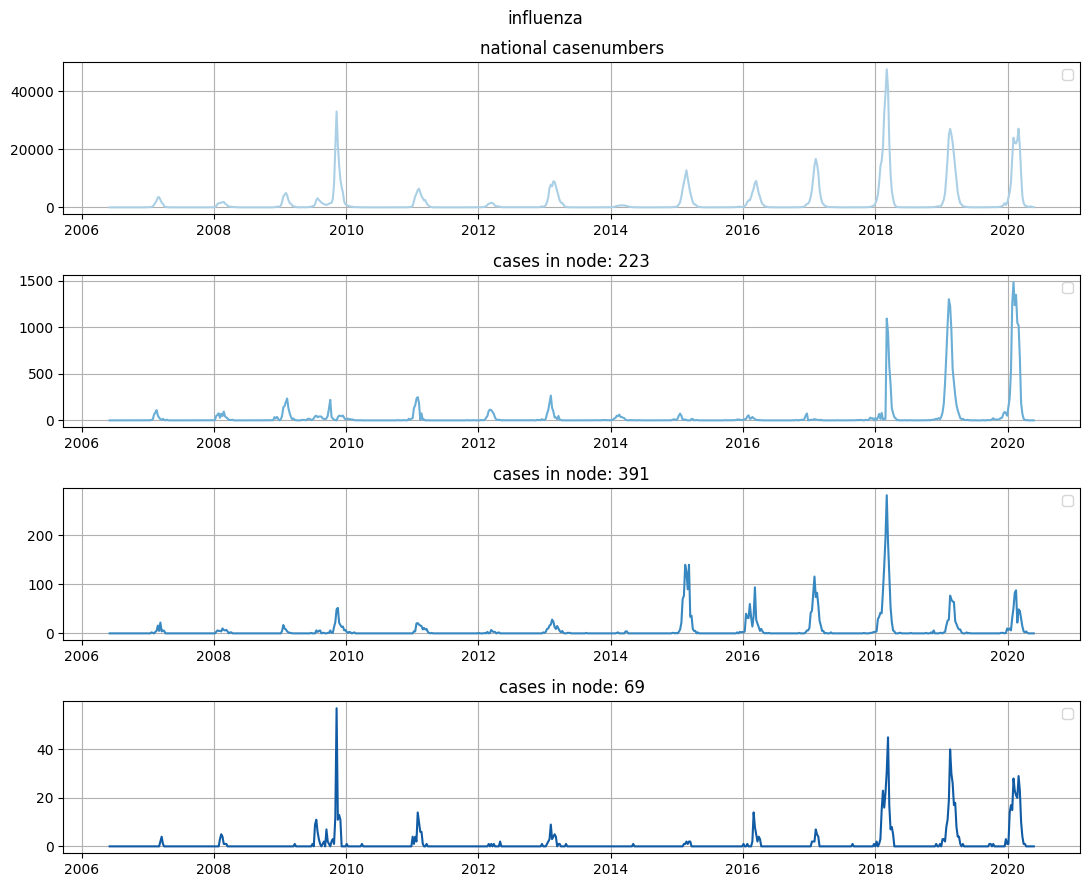

In [3]:
token_munich     = 223
token_jena       = 391
token_oberhausen = 69
token_hannover   = 26

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2006-06-01',max_date='2020-06-01')
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')

epidata.preview([token_munich,token_jena,token_oberhausen],status = 'raw', y ='cases')

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:361: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:374: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1100x900 with 4 Axes>,
 <Axes: title={'center': 'incidence in node: 69'}>)

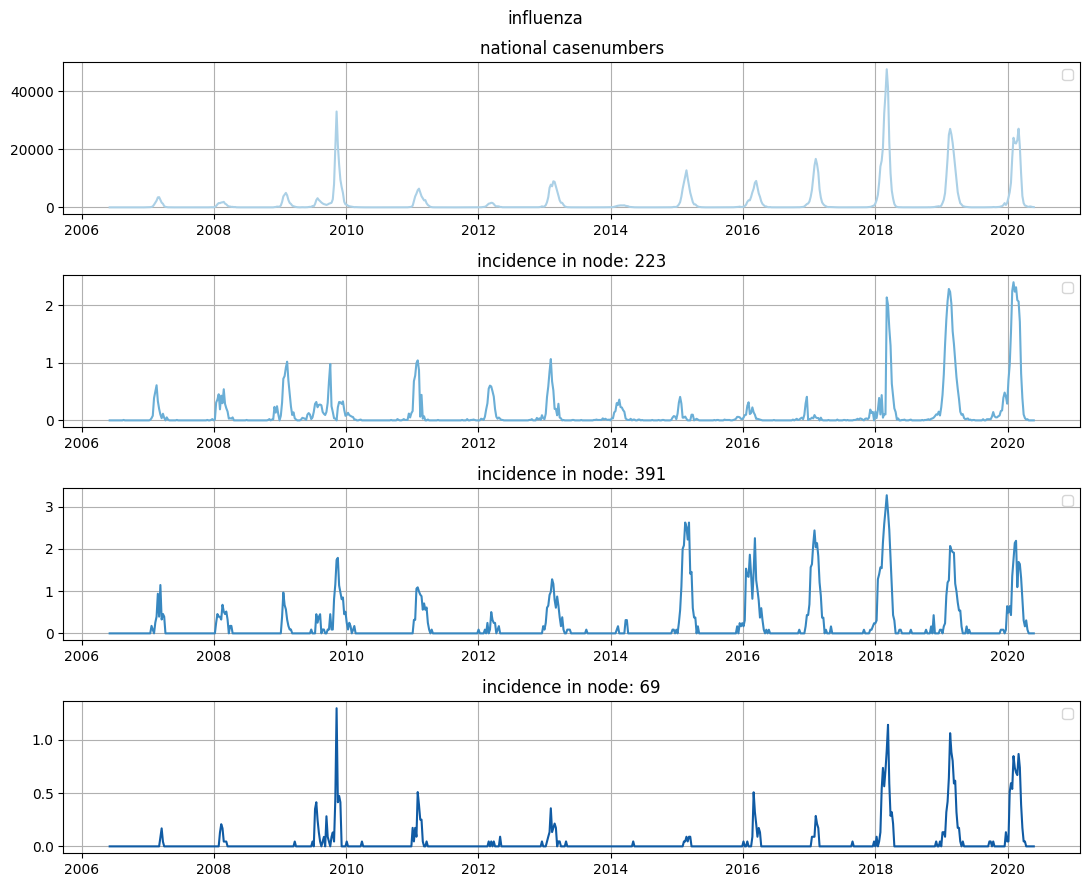

In [11]:
token_munich     = 223
token_jena       = 391
token_oberhausen = 69
token_hannover   = 26

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2006-06-01',max_date='2020-06-01')
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')

epidata.preview([token_munich,token_jena,token_oberhausen],status = 'raw', y ='incidence')

(<Figure size 1100x900 with 4 Axes>, <Axes: title={'center': 'node: 69'}>)

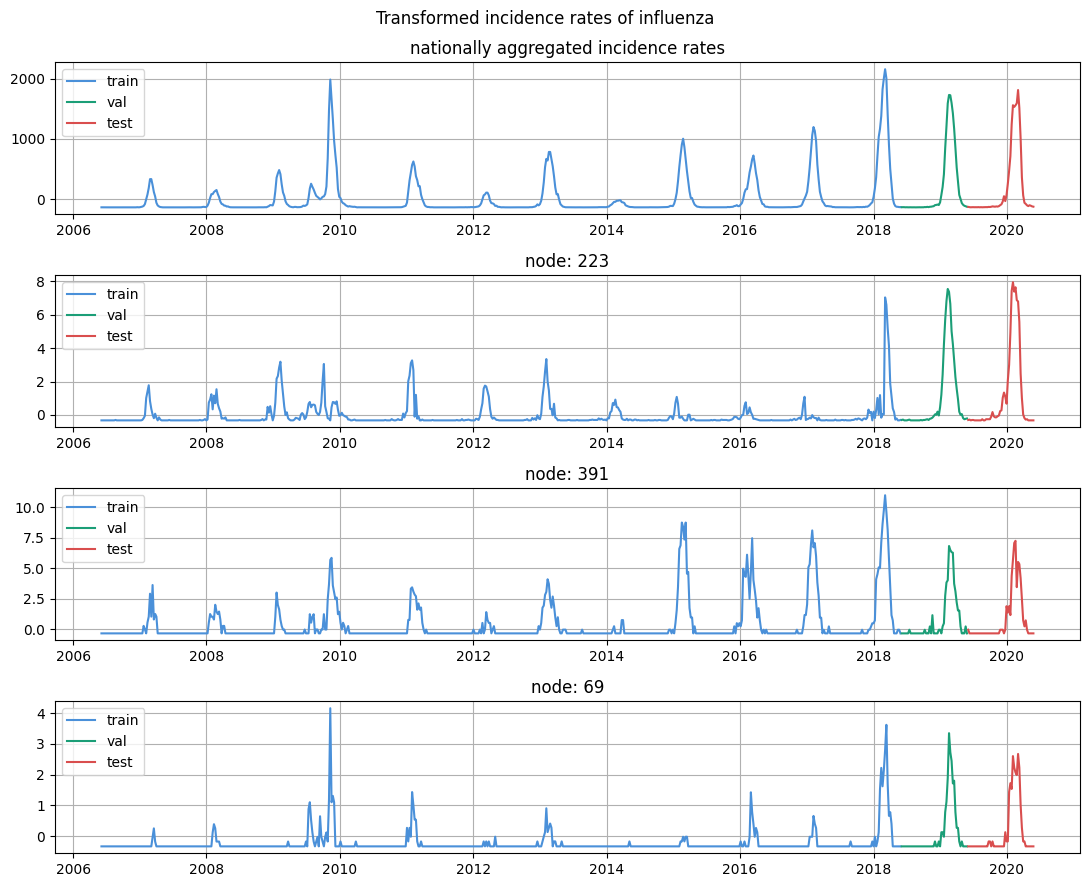

In [4]:
epidata.preview([token_munich,token_jena,token_oberhausen])

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:361: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:374: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1100x900 with 4 Axes>, <Axes: title={'center': 'node: 69'}>)

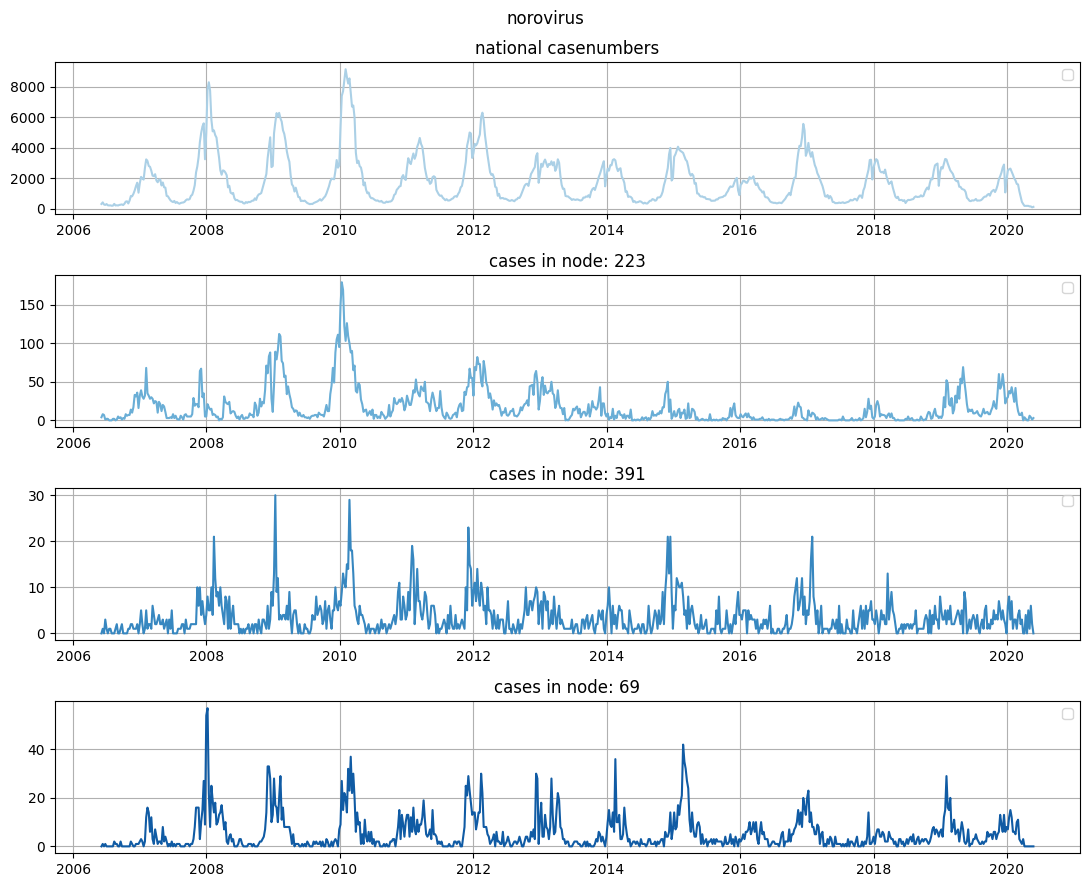

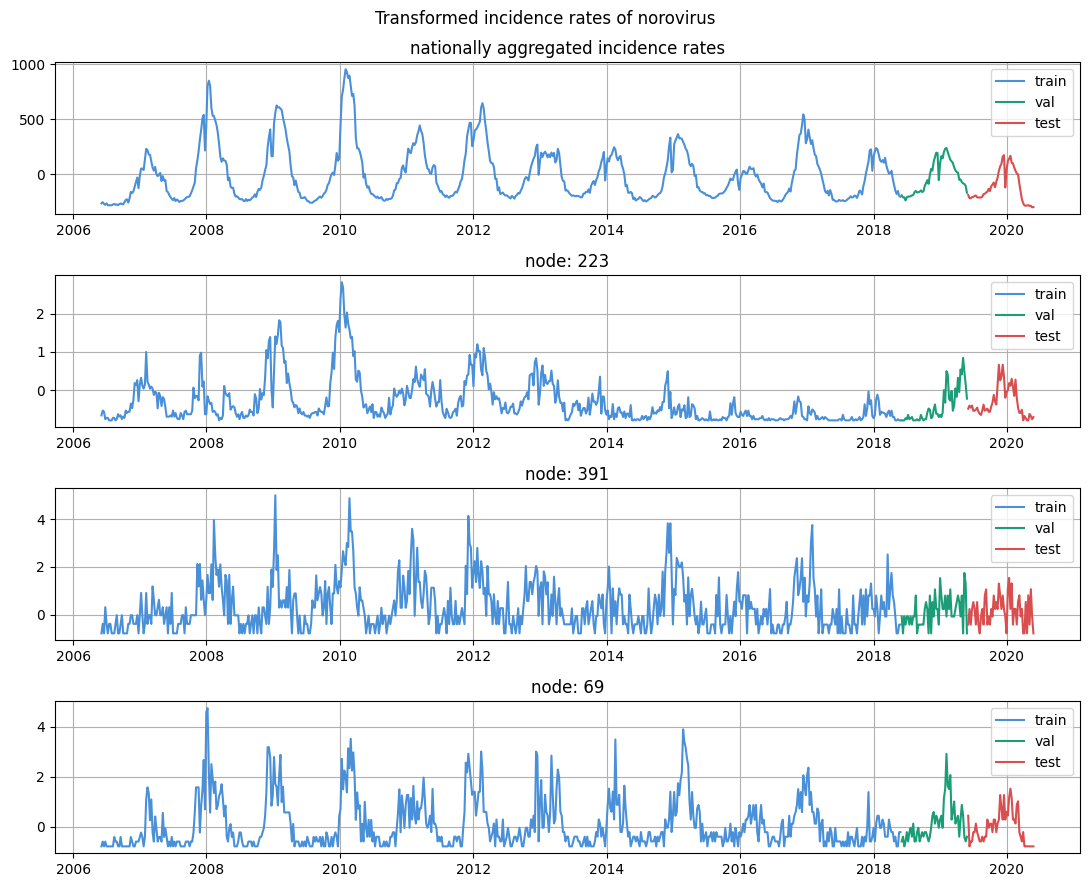

In [5]:
epidata = EpiDataLoader('norovirus', data_env, aggr_level= '03', min_date='2006-06-01',max_date='2020-06-01')
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')

epidata.preview([token_munich,token_jena,token_oberhausen],status = 'raw', y ='cases')

epidata.preview([token_munich,token_jena,token_oberhausen])

# 3. Graphs

In [10]:
from src.dataloading.graphconstructor import GraphConstructor

graphconstruction = GraphConstructor(graph_dir = 'data/graphs', 
                                     population_data = epidata.population_by_node, 
                                     shapes          = epidata.shapedata, 
                                     id_col='node')

graphconstruction.generate_graph(
    method='identity_graph', 
    name_addition='',
    self_connection='1'
)

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    name_addition='self0',
    self_connection='0'
)

graphconstruction.generate_graph(
    method='gravity_model', 
    scaling_method='log',
    max_distance = 250_000,
    alpha = 1.5,
    density_control = 'adaptive',
    name_addition='self0_adaptive',
    self_connection='0'
)

graphconstruction.generate_graph(
    method='gravity_model', 
    scaling_method='log',
    max_distance = 250_000,
    alpha = 1.5,
    density_control = 'distance_bands',
    name_addition='self0_distance_bands',
    self_connection='0'
)

graphconstruction.rename_graph('gravity_model_self0_distance_bands_log', 'gravity_model_sparse')
graphconstruction.rename_graph('gravity_model_self0_adaptive_log', 'gravity_model_dense')

graphconstruction.save_graph('gravity_model_sparse')
graphconstruction.save_graph('gravity_model_dense')


identity_graph generated
boolean_neighbors_self0 generated
gravity_model_self0_adaptive_log generated
gravity_model_self0_distance_bands_log generated
gravity_model_self0_distance_bands_log has been replaced by gravity_model_sparse
gravity_model_self0_adaptive_log has been replaced by gravity_model_dense
edge index gravity_model_sparse saved to data/graphs
edge weight gravity_model_sparse saved to data/graphs
edge index gravity_model_dense saved to data/graphs
edge weight gravity_model_dense saved to data/graphs


/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:279: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


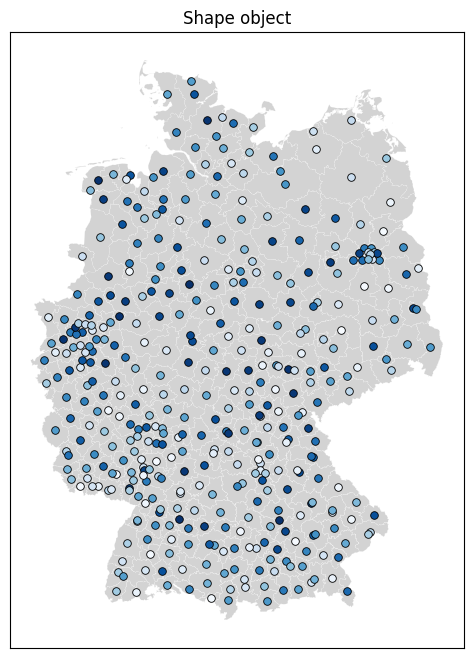

In [6]:
graphconstruction.preview_shape_object()

/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


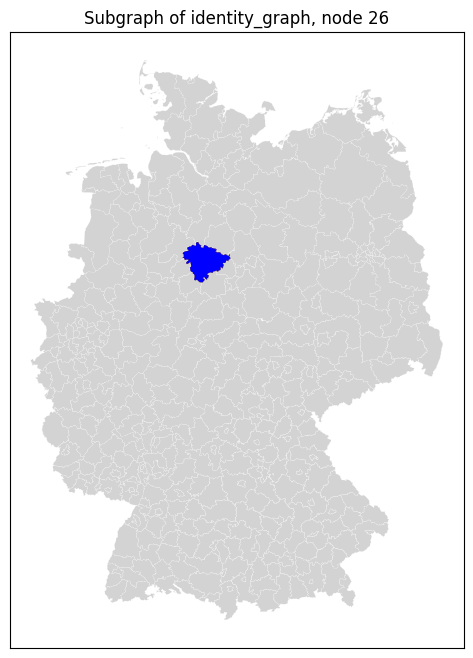

In [10]:
graphconstruction.preview_graph(graphname='identity_graph', node_idx = 26)

/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


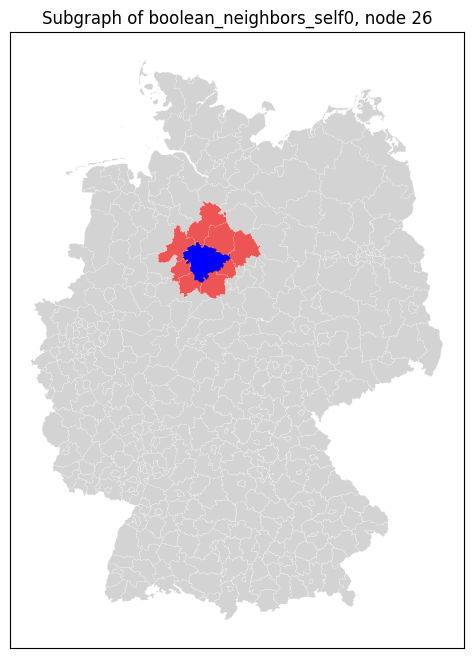

In [7]:
graphconstruction.preview_graph(graphname='boolean_neighbors_self0', node_idx = 26)

/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


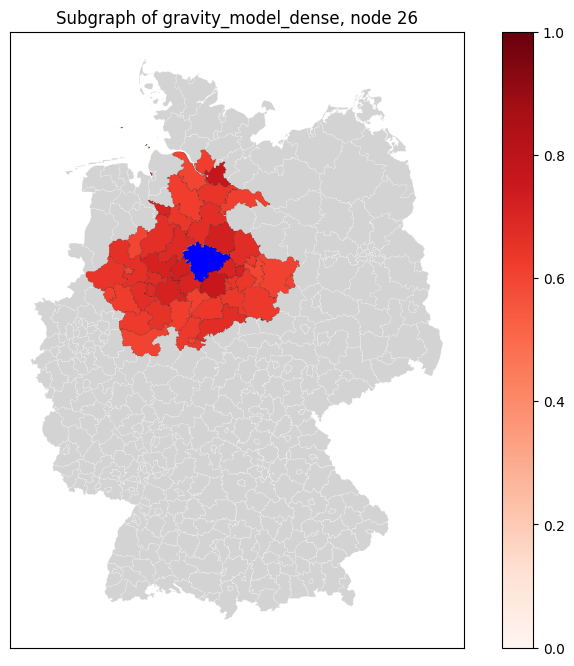

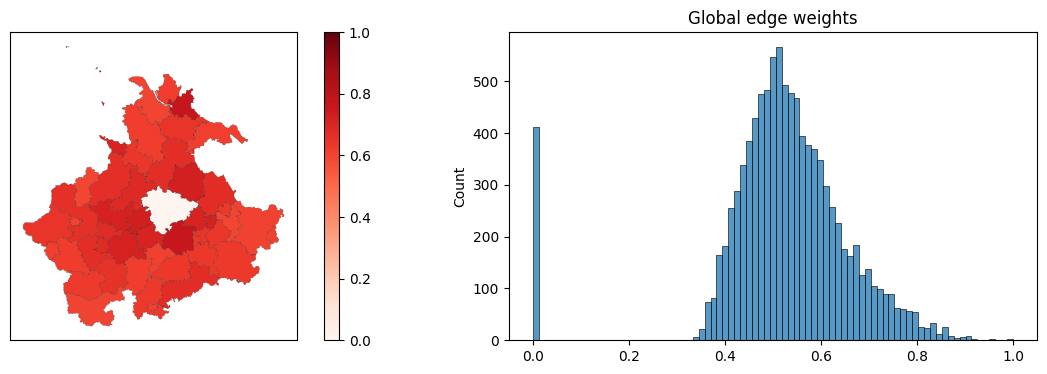

In [8]:
graphconstruction.preview_graph(graphname='gravity_model_dense', node_idx = 26)

/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


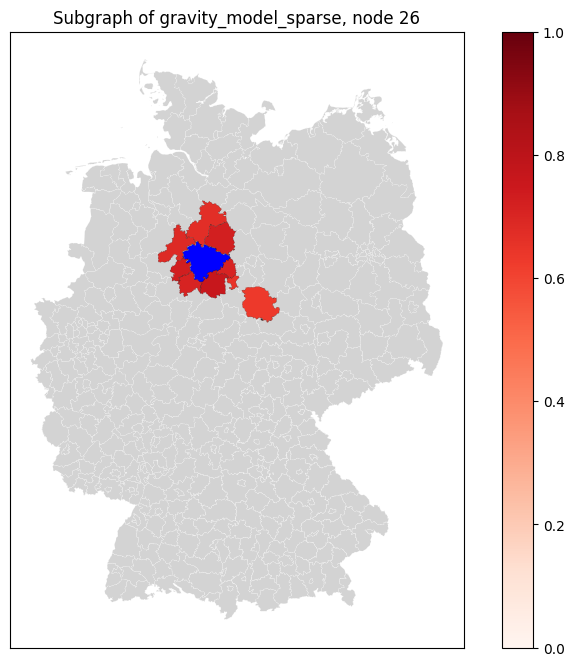

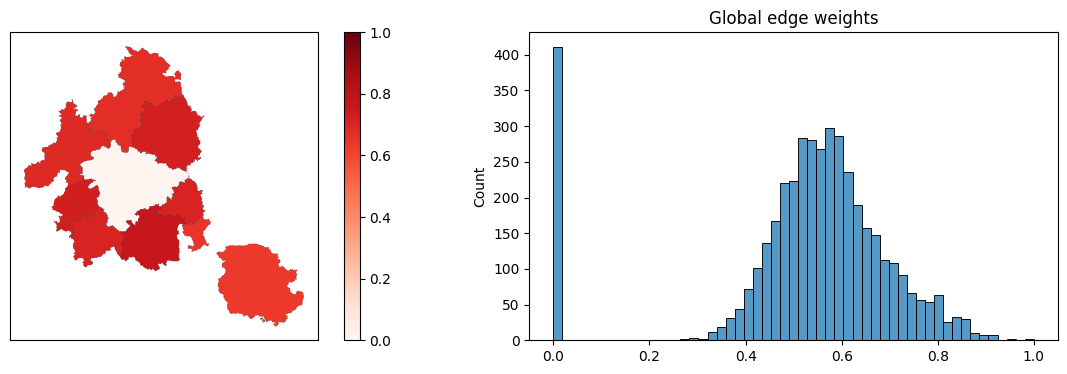

In [9]:
graphconstruction.preview_graph(graphname='gravity_model_sparse', node_idx = 26)